In [ ]:
from pathlib import Path
import sys

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    return start

repo_root = _find_repo_root(Path.cwd())
workspace_root = repo_root.parent
candidate_src_dirs = [
    repo_root / "src",
    workspace_root / "abstractgraph" / "src",
    workspace_root / "abstractgraph-ml" / "src",
    workspace_root / "abstractgraph-generative" / "src",
]
for src_dir in candidate_src_dirs:
    if src_dir.exists():
        src_str = str(src_dir)
        if src_str not in sys.path:
            sys.path.insert(0, src_str)


# Story Graph Roundtrip on Aesop

This notebook demonstrates a strict bidirectional loop:

1. `story text -> story graph`
2. `story graph -> generated story text`
3. re-extract graph from generated text and compare structure


In [1]:
import os

from IPython.display import SVG, display

from abstractgraph_generative.story import (
    ask_llm,
    dump_json,
    extract_story_graph,
    generate_story_with_repair,
    generate_styled_story,
    intention_summary_rows,
    print_graph_semantic_layers,
    load_aesop_fables_from_gutenberg,
    pretty_print_text,
    render_story_graph_dot_svg,
    roundtrip_check,
    select_story,
)

MODEL = os.environ.get("OPENAI_MODEL", "gpt-4o-mini")

DICTIONARY_DIR = "generative/story_graph/resources"


In [2]:
fables = load_aesop_fables_from_gutenberg()
print(f"Loaded {len(fables)} fables.")


Loaded 313 fables.


In [3]:
story_index = 10
doc_id, story_text = select_story(fables, story_index)

print(f"doc_id: {doc_id}")
print('-' * 100)
pretty_print_text(story_text, max_columns=88)


doc_id: aesop_0010
----------------------------------------------------------------------------------------------------
The Ants and the Grasshopper

THE ANTS were spending a fine winter’s day drying grain collected in the summertime. A
Grasshopper, perishing with famine, passed by and earnestly begged for a little food.
The Ants inquired of him, “Why did you not treasure up food during the summer?” He
replied, “I had not leisure enough. I passed the days in singing.” They then said in
derision: “If you were foolish enough to sing all the summer, you must dance supperless
to bed in the winter.”


In [4]:
graph_from_story, stats = extract_story_graph(
    story_text=story_text,
    doc_id=doc_id,
    ask_llm_fn=ask_llm,
    model=MODEL,
    add_node_summaries=True,
    dictionary_dir=DICTIONARY_DIR,
    verbose=True,
)
print(dump_json(stats))


Dictionary stats
----------------------------------------------------------------------------------------------------
{
  "dictionary_dir": "generative/story_graph/resources",
  "vocab_path": "/Users/fabriziocosta/Resilio Sync/Sync/Projects/AbstractGraph/generative/story_graph/resources/vocab_v0.json",
  "sizes": {
    "entity_types": 27,
    "relation_types": 10,
    "event_types": 101,
    "goal_types": 14,
    "intention_types": 23,
    "outcome_types": 5
  },
  "induced_path": "generative/story_graph/resources/induced_closed_alphabet.json",
  "induced_sizes": {
    "entities": 1,
    "relations": 28,
    "goals": 17,
    "intentions": 10,
    "events": 1
  }
}
{
  "doc_id": "aesop_0010",
  "n_nodes": 11,
  "n_edges": 18,
  "n_events": 3,
  "n_entities": 4,
  "n_goals": 2,
  "n_intentions": 2
}


In [5]:
print_graph_semantic_layers(graph_from_story)


Entities
----------------------------------------------------------------------------------------------------
ENT_0001: label=Insect, name=Ants, type=INSECT, role_links=2
  summary: The Ants are diligent characters who prepare for winter by storing food.
ENT_0002: label=Insect, name=Grasshopper, type=INSECT, role_links=2
  summary: The Grasshopper is a carefree character who neglects to store food for winter.
ENT_0003: label=Food, name=Food, type=FOOD, role_links=2
  summary: Food represents the resources that the Ants have stored for winter survival.
ENT_0004: label=Time Unit, name=Summer, type=TIME_UNIT, role_links=1
  summary: Summer is the season during which the Ants gather food.

Relations
----------------------------------------------------------------------------------------------------
No relation nodes extracted.

Goals
----------------------------------------------------------------------------------------------------
GOAL_0001: label=HELP_OTHER, name=Help Other, owner=['Ins

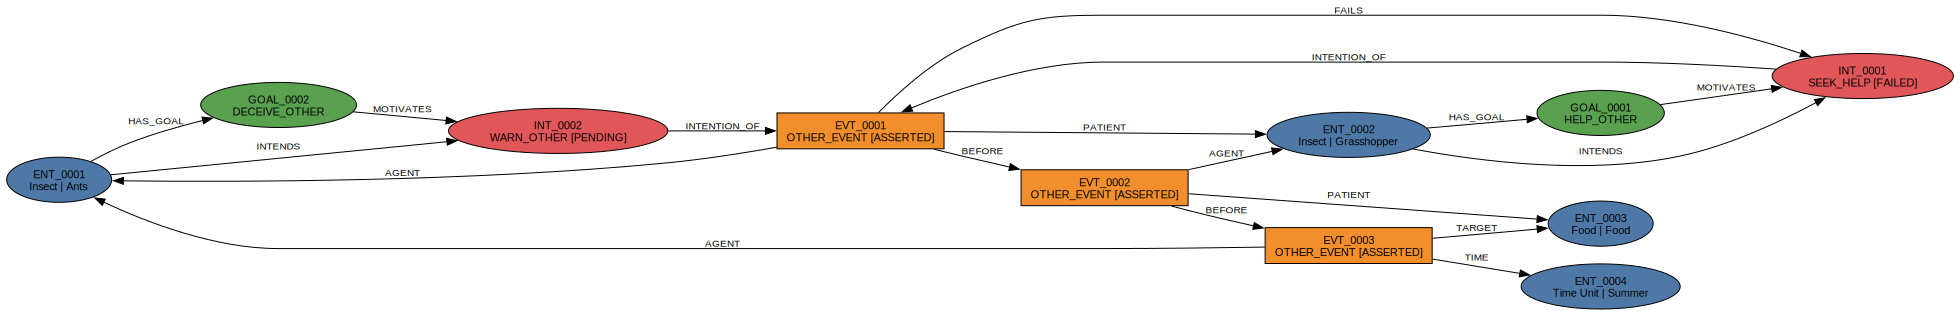

In [6]:
summary_excerpt_sentences = 2
summary_excerpt_chars = 180
dot_svg_path = render_story_graph_dot_svg(
    graph_from_story,
    output_path="notebooks/examples/data/story_graph_roundtrip.dot.svg",
    use_summary=False,
    summary_excerpt_sentences=summary_excerpt_sentences,
    summary_excerpt_chars=summary_excerpt_chars,
)
display(SVG(filename=dot_svg_path))


In [7]:
generated_story, plan, repair_info = generate_story_with_repair(
    graph_from_story,
    ask_llm_fn=ask_llm,
    model=MODEL,
    temperature=0.2,
    max_output_tokens=1200,
    dictionary_dir=DICTIONARY_DIR,
)

print('Generated story from graph:')
print('-' * 100)
pretty_print_text(generated_story, max_columns=88)
print('-' * 100)
print('Repair diagnostics:')
print(dump_json(repair_info))
print(f"Planned events: {len(plan)}")
plan

Generated story from graph:
----------------------------------------------------------------------------------------------------
The Grasshopper begs the Ants for food during winter. The Ants question the Grasshopper
about his lack of food preparation. The Ants mock the Grasshopper for his lack of
foresight.
----------------------------------------------------------------------------------------------------
Repair diagnostics:
{
  "repaired": true,
  "sequence_match": false,
  "repair_attempts": 2
}
Planned events: 3


[{'order': 1,
  'event_id': 'EVT_0001',
  'event_type': 'GIVE',
  'modality': 'ASSERTED',
  'summary_text': 'The Grasshopper begs the Ants for food during winter.',
  'evidence_text': 'The Grasshopper... earnestly begged for a little food.',
  'sentence_id': 'S0001',
  'roles': {'AGENT': 'ENT_0001', 'PATIENT': 'ENT_0002'},
  'motives': [],
  'intention_effects': [('FAILS', 'ENT_0002', 'SEEK_HELP')]},
 {'order': 2,
  'event_id': 'EVT_0002',
  'event_type': 'ASK',
  'modality': 'ASSERTED',
  'summary_text': 'The Ants question the Grasshopper about his lack of food preparation.',
  'evidence_text': "The Ants inquired of him, 'Why did you not treasure up food during the summer?'",
  'sentence_id': 'S0002',
  'roles': {'AGENT': 'ENT_0002', 'PATIENT': 'ENT_0003'},
  'motives': [],
  'intention_effects': []},
 {'order': 3,
  'event_id': 'EVT_0003',
  'event_type': 'SPEAK',
  'modality': 'ASSERTED',
  'summary_text': 'The Ants mock the Grasshopper for his lack of foresight.',
  'evidence_text'

In [8]:
style_prompt = (
    "Keep an Aesop-like fable tone with vivid but compact descriptive detail, "
    "short dialogue when useful, and a clear moral cadence at the end."
)

styled_story = generate_styled_story(
    generated_story=generated_story,
    style_prompt=style_prompt,
    ask_llm_fn=ask_llm,
    model=MODEL,
    temperature=0.3,
    max_output_tokens=1400,
)

print('Styled detailed rendering:')
print('-' * 100)
pretty_print_text(styled_story, max_columns=88)


Styled detailed rendering:
----------------------------------------------------------------------------------------------------
As the chill of winter settled over the land, a solitary Grasshopper found himself
shivering beneath a barren tree, his vibrant green body now a stark contrast against the
white blanket of snow. With a rumbling stomach, he approached the bustling Ants, who
were diligently storing their provisions for the long, cold months ahead.

“Please, kind Ants,” he pleaded, his voice trembling with desperation, “I am hungry and
have nothing to eat. Might you spare a morsel from your bounty?”

The Ants paused in their work, their antennae twitching with curiosity. One of them, a
stout Ant with a gleaming shell, stepped forward and asked, “Why did you not prepare for
winter, Grasshopper? Did you not see the signs of the changing season?”

The Grasshopper, his eyes wide with regret, replied, “I was so caught up in the warmth
of summer, singing and dancing, that I did not thi

In [9]:
check, graph_from_generated = roundtrip_check(
    original_graph=graph_from_story,
    generated_story=generated_story,
    ask_llm_fn=ask_llm,
    model=MODEL,
    add_node_summaries=True,
    dictionary_dir=DICTIONARY_DIR,
)

print('Roundtrip check: story -> graph -> story -> graph')
print(dump_json(check))
if check.get('first_mismatch'):
    print('First mismatch:', check['first_mismatch'])


Roundtrip check: story -> graph -> story -> graph
{
  "n_events_original": 3,
  "n_events_regenerated": 3,
  "event_count_match": true,
  "event_type_and_role_sequence_match": false,
  "first_mismatch": {
    "index": 0,
    "original": [
      "GIVE",
      [
        [
          "AGENT",
          "ants"
        ],
        [
          "PATIENT",
          "grasshopper"
        ]
      ]
    ],
    "regenerated": [
      "GIVE",
      [
        [
          "AGENT",
          "grasshopper"
        ],
        [
          "RECIPIENT",
          "ants"
        ],
        [
          "TIME",
          "winter"
        ]
      ]
    ]
  }
}
First mismatch: {'index': 0, 'original': ('GIVE', (('AGENT', 'ants'), ('PATIENT', 'grasshopper'))), 'regenerated': ('GIVE', (('AGENT', 'grasshopper'), ('RECIPIENT', 'ants'), ('TIME', 'winter')))}
